In [1]:
%matplotlib inline
from pathlib import Path
from matplotlib.pyplot import *
import numpy as np
from numpy.polynomial.polynomial import polyfit

working_dir = Path.cwd()
repo_root = working_dir.parent if (working_dir / 'scaley_kmb_mod.ipynb').exists() else working_dir
figure_dir = repo_root / 'paper'

In [2]:
def scaleR(R,S):
    return R*np.power(S,1.5)
def scaleR1(R,S):
    return R*np.power(S,1)
def scaleR2(R,S):
    return R*np.power(S,2)

Text(0, 0.5, 'Rate(> 1Jy.ms)')

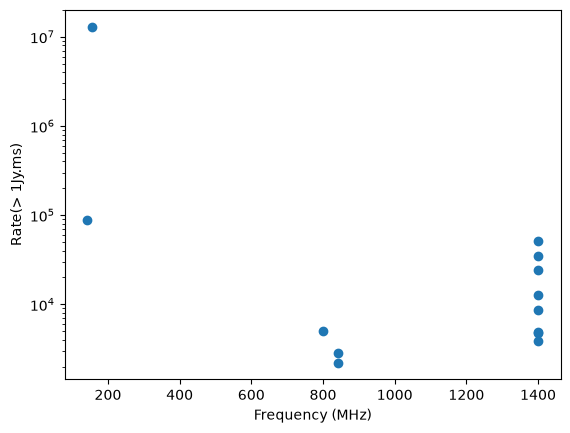

In [3]:
figure()
# Historical exploratory fit; later cells contain the canonical data and error treatment.
rates = [scaleR(225,6.7), scaleR(1e4,3), scaleR(1.5e2,107*0.66), scaleR(700,700), scaleR(4400,4), scaleR(7000,1.5), scaleR(3300,3.8),scaleR(587,6), scaleR(5,69), scaleR(1.7e3,2),scaleR(37,26), scaleR(98,8), scaleR(5e3,1)]
freq = [1400, 1400, 142, 155, 1400, 1400, 1400, 1400, 843, 1400, 1400, 843, 800]
plot(freq, rates, 'o')
# Fit
freqs = np.arange(100, 1500)
#b, m = polyfit(freq, rates, 1)
#plot(freqs, -500 + 1.5 * freqs, '-')
yscale("log")
xlabel("Frequency (MHz)")
ylabel("Rate(> 1Jy.ms)")

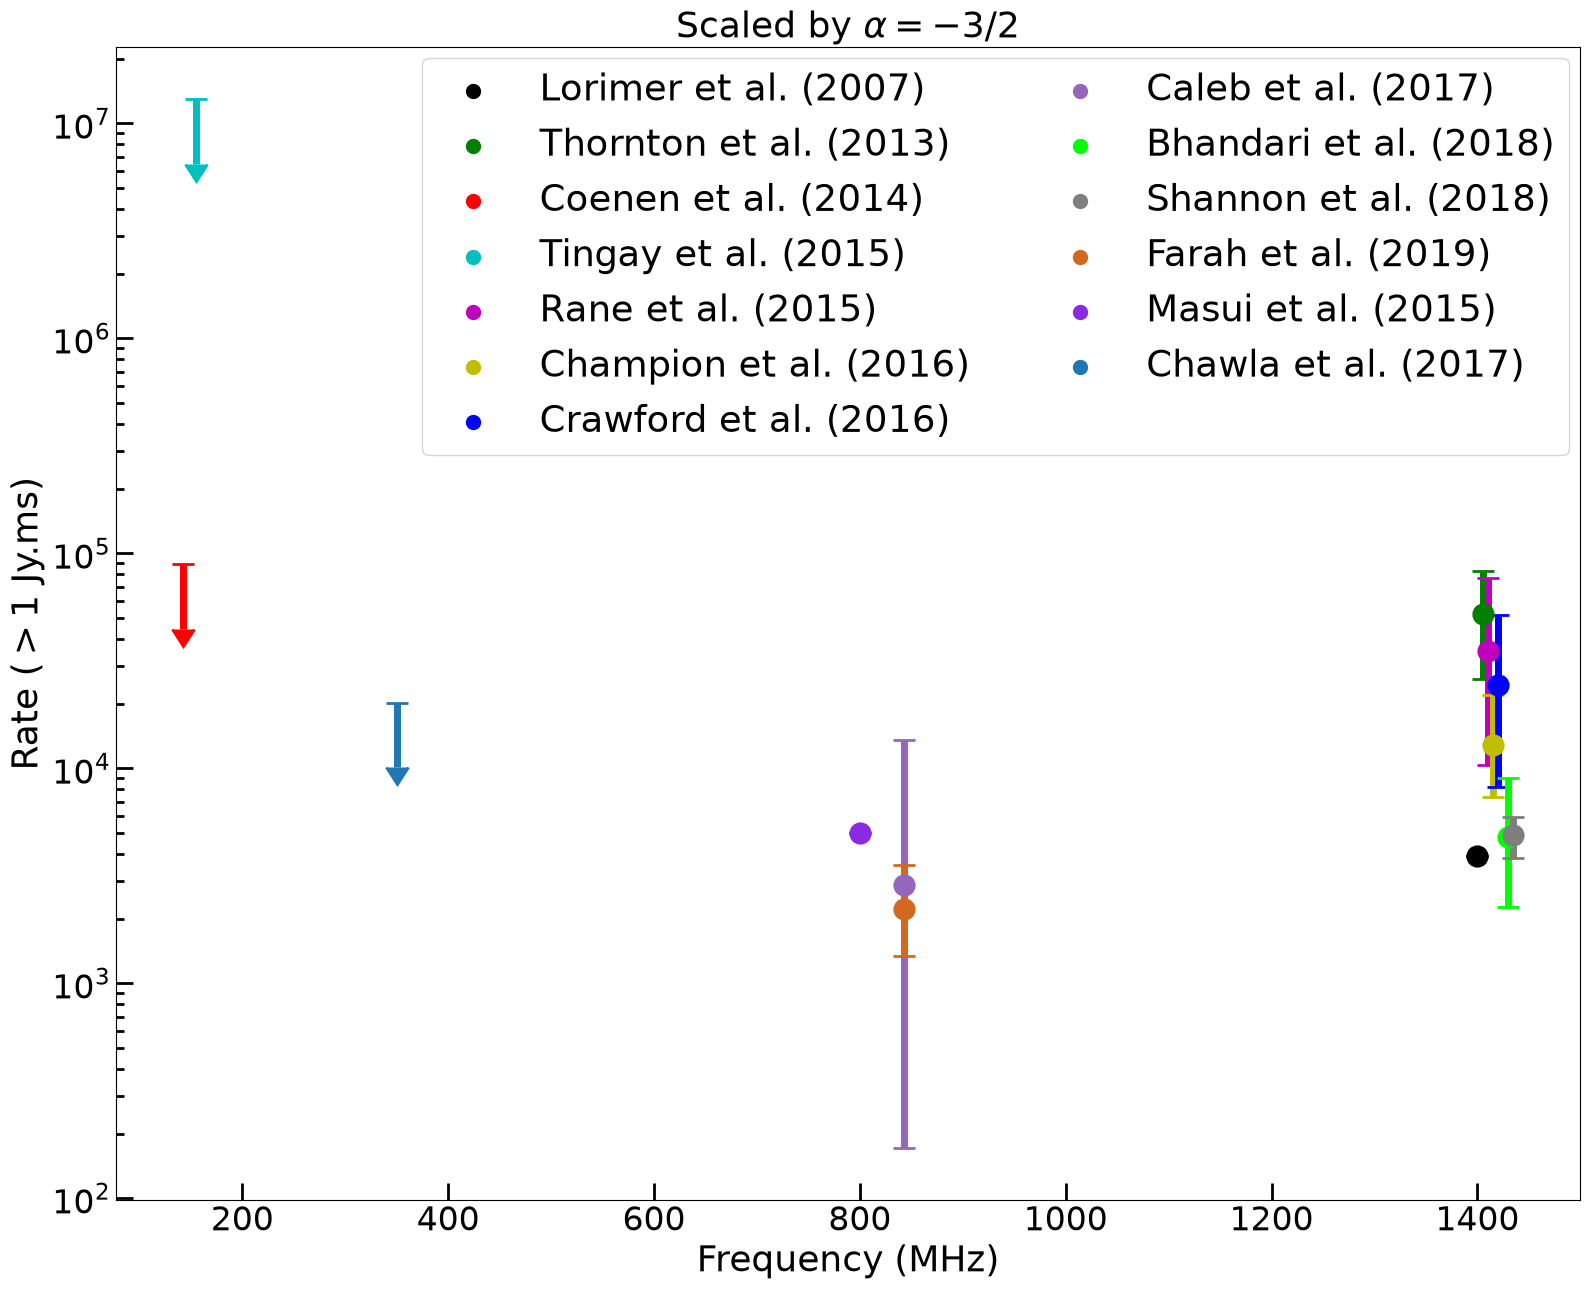

In [4]:

def scaleR(R,S):
    return R*np.power(S,1.5)


surveys = [
'Lorimer et al. (2007)',
'Thornton et al. (2013)',
'Coenen et al. (2014)',
'Tingay et al. (2015)',
'Rane et al. (2015)',
'Champion et al. (2016)',
'Crawford et al. (2016)',
'Caleb et al. (2017)',
'Bhandari et al. (2018)',
'Shannon et al. (2018)',
'Farah et al. (2019)',
'Masui et al. (2015)',
'Chawla et al. (2017)'
]

rates = [scaleR(225,6.7), 
         scaleR(1e4,3), 
         scaleR(1.5e2,107*0.66), 
         scaleR(700,700), 
         scaleR(4400,4), 
         scaleR(7000,1.5), 
         scaleR(3300,3.8),
         scaleR(5,69), 
         scaleR(1.7e3,2),
         scaleR(37,26), 
         scaleR(98,8), 
         scaleR(5e3,1),
        scaleR(3620,3.15)]

freq = [1400, 
        1405, 
        142, 
        155, 
        1410, 
        1415, 
        1420, 
        843, 
        1430, 
        1435, 
        843, 
        800,
       350]

# lower & upper limits of the error
lolims = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=bool)
uplims = np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=bool)
marker =          ['o','o','-','-','o','o','o','o','o','o','o','o','-']
colors =          ['k','g','r','c','m','y','b','tab:purple','lime','tab:gray','chocolate','blueviolet','tab:blue']


# Matplotlib expects positive distances from each central value, not interval endpoints.
yerr_up = np.array([0, scaleR(0.6e4,3), 0, 0, scaleR(5.2e3,4), scaleR(5e3,1.5), scaleR(3.7e3,3.8), scaleR(18.7,69), scaleR(1.5e3,2), scaleR(8,26), scaleR(59,8), 0, 0])
yerr_low = np.array([0, scaleR(0.5e4,3), 0, 0, scaleR(3.1e3,4), scaleR(3e3,1.5), scaleR(2.2e3,3.8), scaleR(4.7,69), scaleR(0.9e3,2), scaleR(8,26), scaleR(39,8), 0, 0])
# Arrow length for upper-limit observations is presentational.
yerr_low[uplims] = 0.5 * np.asarray(rates)[uplims]

fig, ax = subplots(figsize=(16, 13))
# Looping through the letters and plotting the points
for i in np.arange(0,13):
    ax.errorbar(freq[i], rates[i], ms = 14, mew = 2,yerr=[[yerr_low[i]], [yerr_up[i]]], fmt=marker[i], color=colors[i], capsize=8, elinewidth=5, lolims=lolims[i], uplims=uplims[i])
    ax.scatter([],[],color = colors[i], label = surveys[i], s = 100)        
#style.use('classic')


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 26,
        }

#rc('font', size=18)          # controls default text sizes
#rc('axes', titlesize=20)     # fontsize of the axes title
#rc('axes', labelsize=20)    # fontsize of the x and y labels
#rc('xtick', labelsize=26)    # fontsize of the tick labels
#rc('ytick', labelsize=26)    # fontsize of the tick labels
rc('legend', fontsize=26.5)    # legend fontsize
rc('figure', titlesize=26.5)  # fontsize of the figure title

xticks(fontsize='24')
yticks(fontsize='24')
#ax.legend(loc='best', frameon=True)  
#ax.legend( loc='bottom',
#           , mode="expand", borderaxespad=0.)
ax.legend(bbox_to_anchor=(1,1), ncol=2, borderaxespad=0.3)
yscale("log")
xlabel(r'Frequency (MHz)',fontdict=font)
ylabel(r'Rate ($> 1 $ Jy.ms)', fontdict=font)
title(r'Scaled by $\alpha = -3/2$',fontdict=font)
ax.tick_params(which='both', direction = 'in')
ax.tick_params(which='major', length=12, width = 2)
ax.tick_params(which='minor', length=6, width = 2)
               
tight_layout()
savefig(figure_dir / 'frbrate_alpha15.png')
#ylim(100,400000)

In [5]:
# The canonical alpha=-3/2 figure is saved in the plotting cell above.

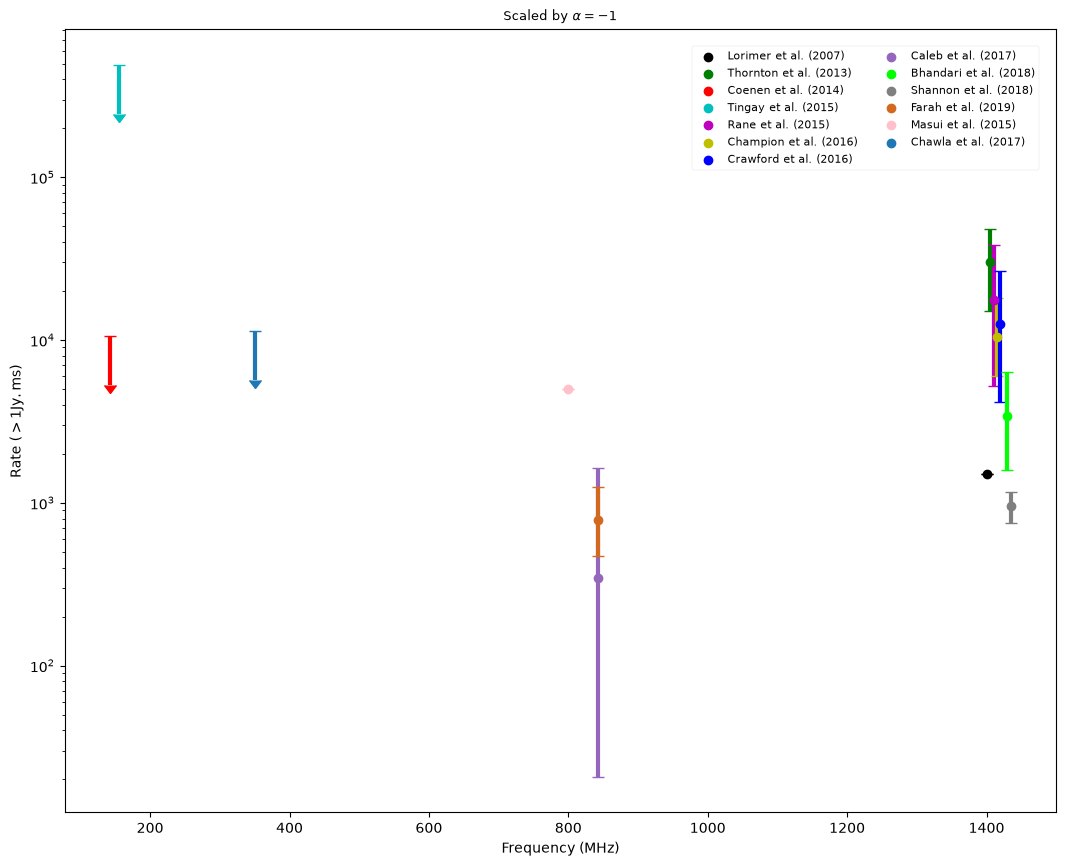

In [6]:
def scaleR(R,S):
    return R*np.power(S,1)


surveys = [
'Lorimer et al. (2007)',
'Thornton et al. (2013)',
'Coenen et al. (2014)',
'Tingay et al. (2015)',
'Rane et al. (2015)',
'Champion et al. (2016)',
'Crawford et al. (2016)',
'Caleb et al. (2017)',
'Bhandari et al. (2018)',
'Shannon et al. (2018)',
'Farah et al. (2019)',
'Masui et al. (2015)',
'Chawla et al. (2017)'
]

rates = [scaleR(225,6.7), 
         scaleR(1e4,3), 
         scaleR(1.5e2,107*0.66), 
         scaleR(700,700), 
         scaleR(4400,4), 
         scaleR(7000,1.5), 
         scaleR(3300,3.8),
         scaleR(5,69), 
         scaleR(1.7e3,2),
         scaleR(37,26), 
         scaleR(98,8), 
         scaleR(5e3,1),
        scaleR(3620,3.15)]

freq = [1400, 
        1405, 
        142, 
        155, 
        1410, 
        1415, 
        1420, 
        843, 
        1430, 
        1435, 
        843, 
        800,
       350]

# lower & upper limits of the error
lolims = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=bool)
uplims = np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=bool)
marker =          ['o','o','-','-','o','o','o','o','o','o','o','o','-']
colors =          ['k','g','r','c','m','y','b','tab:purple','lime','tab:gray','chocolate','pink','tab:blue']


# Matplotlib expects positive distances from each central value, not interval endpoints.
yerr_up = np.array([0, scaleR(0.6e4,3), 0, 0, scaleR(5.2e3,4), scaleR(5e3,1.5), scaleR(3.7e3,3.8), scaleR(18.7,69), scaleR(1.5e3,2), scaleR(8,26), scaleR(59,8), 0, 0])
yerr_low = np.array([0, scaleR(0.5e4,3), 0, 0, scaleR(3.1e3,4), scaleR(3e3,1.5), scaleR(2.2e3,3.8), scaleR(4.7,69), scaleR(0.9e3,2), scaleR(8,26), scaleR(39,8), 0, 0])
# Arrow length for upper-limit observations is presentational.
yerr_low[uplims] = 0.5 * np.asarray(rates)[uplims]

fig, ax = subplots(figsize=(11, 9))
# Looping through the letters and plotting the points
for i in np.arange(0,13):
    ax.errorbar(freq[i], rates[i], yerr=[[yerr_low[i]], [yerr_up[i]]], fmt=marker[i], color=colors[i], capsize=4, elinewidth=3, lolims=lolims[i], uplims=uplims[i])
    ax.scatter([],[],color = colors[i], label = surveys[i])        

style.use('seaborn-v0_8-paper')
rc('font', size=18)          # controls default text sizes
#rc('axes', titlesize=16)     # fontsize of the axes title
#rc('axes', labelsize=16)    # fontsize of the x and y labels
rc('xtick', labelsize=16)    # fontsize of the tick labels
rc('ytick', labelsize=16)    # fontsize of the tick labels
#rc('legend', fontsize=16)    # legend fontsize
#rc('figure', titlesize=sz)  # fontsize of the figure title

#ax.legend(loc='best', frameon=True)  
#ax.legend( loc='bottom',
#           , mode="expand", borderaxespad=0.)
ax.legend(bbox_to_anchor=(1,1), loc='best', ncol=2, borderaxespad=1.5)
yscale("log")
xlabel(r'Frequency (MHz)')
ylabel(r'Rate $(> 1 \rm{Jy.ms})$')
title(r'Scaled by $\alpha = -1$')
tight_layout()
savefig('frbrate_alpha1.png')
#ylim(100,400000)

In [7]:
# The exploratory alpha=-1 figure is saved in the plotting cell above.

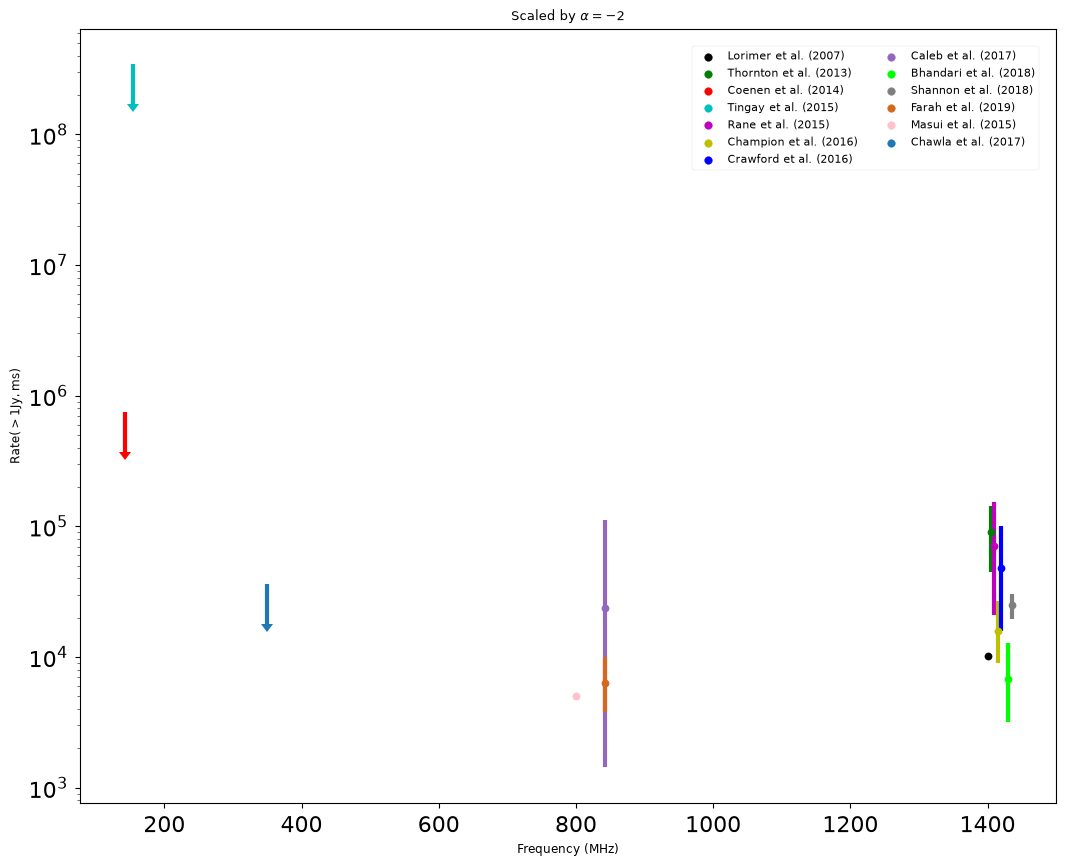

In [8]:

def scaleR(R,S):
    return R*np.power(S,2)


surveys = [
'Lorimer et al. (2007)',
'Thornton et al. (2013)',
'Coenen et al. (2014)',
'Tingay et al. (2015)',
'Rane et al. (2015)',
'Champion et al. (2016)',
'Crawford et al. (2016)',
'Caleb et al. (2017)',
'Bhandari et al. (2018)',
'Shannon et al. (2018)',
'Farah et al. (2019)',
'Masui et al. (2015)',
'Chawla et al. (2017)'
]

rates = [scaleR(225,6.7), 
         scaleR(1e4,3), 
         scaleR(1.5e2,107*0.66), 
         scaleR(700,700), 
         scaleR(4400,4), 
         scaleR(7000,1.5), 
         scaleR(3300,3.8),
         scaleR(5,69), 
         scaleR(1.7e3,2),
         scaleR(37,26), 
         scaleR(98,8), 
         scaleR(5e3,1),
        scaleR(3620,3.15)]

freq = [1400, 
        1405, 
        142, 
        155, 
        1410, 
        1415, 
        1420, 
        843, 
        1430, 
        1435, 
        843, 
        800,
       350]

# lower & upper limits of the error
lolims = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=bool)
uplims = np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=bool)
marker =          ['o','o','-','-','o','o','o','o','o','o','o','o','-']
colors =          ['k','g','r','c','m','y','b','tab:purple','lime','tab:gray','chocolate','pink','tab:blue']


# Matplotlib expects positive distances from each central value, not interval endpoints.
yerr_up = np.array([0, scaleR(0.6e4,3), 0, 0, scaleR(5.2e3,4), scaleR(5e3,1.5), scaleR(3.7e3,3.8), scaleR(18.7,69), scaleR(1.5e3,2), scaleR(8,26), scaleR(59,8), 0, 0])
yerr_low = np.array([0, scaleR(0.5e4,3), 0, 0, scaleR(3.1e3,4), scaleR(3e3,1.5), scaleR(2.2e3,3.8), scaleR(4.7,69), scaleR(0.9e3,2), scaleR(8,26), scaleR(39,8), 0, 0])
# Arrow length for upper-limit observations is presentational.
yerr_low[uplims] = 0.5 * np.asarray(rates)[uplims]

fig, ax = subplots(figsize=(11, 9))
# Looping through the letters and plotting the points
for i in np.arange(0,13):
    ax.errorbar(freq[i], rates[i], yerr=[[yerr_low[i]], [yerr_up[i]]], fmt=marker[i], color=colors[i], capsize=4, elinewidth=3, lolims=lolims[i], uplims=uplims[i])
    ax.scatter([],[],color = colors[i], label = surveys[i])        

    
rc('font', size=18)          # controls default text sizes
#rc('axes', titlesize=16)     # fontsize of the axes title
#rc('axes', labelsize=16)    # fontsize of the x and y labels
#rc('xtick', labelsize=16)    # fontsize of the tick labels
#rc('ytick', labelsize=16)    # fontsize of the tick labels
#rc('legend', fontsize=16)    # legend fontsize
#rc('figure', titlesize=sz)  # fontsize of the figure title

#ax.legend(loc='best', frameon=True)  
#ax.legend( loc='bottom',
#           , mode="expand", borderaxespad=0.)
ax.legend(bbox_to_anchor=(1,1), loc='best', ncol=2, borderaxespad=1.5)
yscale("log")
xlabel(r'Frequency (MHz)')
ylabel(r'$\rm{Rate} (> 1 \rm{Jy.ms})$')
title(r'Scaled by $\alpha = -2$')
tight_layout()
savefig('frbrate_alpha2.png')
#ylim(100,400000)

In [9]:
# The exploratory alpha=-2 figure is saved in the plotting cell above.